# News Encoder → Survey Expectation Pipeline

**Goal:** Calibrate a frozen FinBERT encoder + Random Forest regression to map
aggregated financial-news embeddings to median survey forecasts (dividend and
earnings growth expectations), then evaluate via walk-forward expanding-window
cross-validation and extrapolate the fitted map backward through history.

**Pipeline stages:**

1. Load news corpus and survey data
2. Encode articles with frozen FinBERT (`ProsusAI/finbert`)
3. Aggregate article embeddings within each survey wave window (recency-weighted)
4. Tune Random Forest hyperparameters once via LOO-CV on the initial training window
5. Walk-forward expanding-window evaluation — train on all waves up to *t*, predict *t+1*
6. Refit final model on full calibration set at tuned hyperparameters
7. Explainability: vocabulary saliency word clouds, attention × gradient attribution,
   feature importance factor interpretation, wave influence (Cook's D), temporal saliency
8. Historical extrapolation to pre-survey period

**TODO markers** indicate cells requiring data paths or manual tuning.

## 1. Setup

In [1]:
#conda update --all

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device (encoder only — RF runs on CPU)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Encoder device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Encoder device: cuda
GPU: NVIDIA GeForce RTX 2080 Ti


## 2. Configuration

**TODO:** review and tune as needed.

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("./data")
CACHE_DIR  = Path("./cache")
OUTPUT_DIR = Path("./output")
for d in [CACHE_DIR, OUTPUT_DIR]:
    d.mkdir(exist_ok=True, parents=True)

# ── Encoder ───────────────────────────────────────────────────────────────────
ENCODER_NAME    = "ProsusAI/finbert"
MAX_TOKEN_LEN   = 512
ENCODE_BATCH    = 32

# ── Aggregation ───────────────────────────────────────────────────────────────
AGG_WINDOW_DAYS       = 30
RECENCY_WEIGHTING     = "exponential"   # "uniform" | "exponential"
RECENCY_HALFLIFE_DAYS = 7

# ── Sentiment filtering ───────────────────────────────────────────────────────
NEUTRAL_THRESHOLD      = 0.90
NEUTRAL_THRESHOLD_GRID = [0.75, 0.85, 0.90, 0.95, 1.01]  # 1.01 = no filtering
SENTIMENT_BATCH        = 64

# ── Within-wave variance features ─────────────────────────────────────────────
# Disabled for both series.
#   dividend_growth: too few articles per wave to estimate variance reliably.
#   earnings_growth: doubling to 1536 dims with max_features=0.05 leaves the
#     forest seeing only ~77 features per split — too sparse; gains don't
#     justify the added dimensionality at current N.
USE_VARIANCE_FEATURES = {
    "dividend_growth": False,
    "earnings_growth": False,
}

# ── Walk-forward evaluation ───────────────────────────────────────────────────
# dividend_growth: 49 waves → 30 initial (leaves 19 eval steps, more robust
#   aggregate metrics than the previous 9 steps).
# earnings_growth: 157 waves → 40 initial (leaves 117 eval steps).
MIN_TRAIN_WAVES_PER_SERIES = {
    "dividend_growth": 30,
    "earnings_growth": 40,
}
MIN_TRAIN_WAVES = 40    # fallback for any series not in dict above

# ── Random Forest hyperparameter grid (LOO-CV on initial window) ──────────────
RF_N_ESTIMATORS      = 500
RF_MAX_FEATURES_GRID = ["sqrt", "log2", 0.05, 0.10]
# min_samples_leaf floor raised to 2 — leaf size of 1 memorises individual
# waves at N < 150 and LOO-CV is too noisy to reliably penalise it.
RF_MSL_GRID          = [2, 3, 5, 8, 13, 20, 30]

# ── Mahalanobis support check ─────────────────────────────────────────────────
PCA_COMPONENTS_MAHAL = 30

## 3. Load News Corpus

**TODO:** plug in your news data here. Expected schema:

| column   | type        | description                              |
|----------|-------------|------------------------------------------|
| `date`   | datetime    | publication date                         |
| `text`   | str         | article body (or headline + lede)        |
| `source` | str (opt.)  | publisher, e.g.\ "WSJ", "FT", "Bloomberg" |

The script below is a placeholder that creates a small dummy DataFrame so you can
verify the pipeline end-to-end before plugging in real data. **Replace this cell**
with your actual data load (CSV, Parquet, SQL, etc.).

In [4]:
# TODO: set the path to your parquet file
NEWS_PARQUET = DATA_DIR / "wsj_headlines_1965_2014_zstd.parquet"   # <-- fill in filename

# TODO: set the column names as they appear in your parquet
NEWS_DATE_COL   = "date"    # column containing article publication date
NEWS_TEXT_COL   = "headline"    # column containing article body / lede
NEWS_SOURCE_COL = None      # column for publisher, or None if absent


def load_news_corpus():
    '''Load news corpus from parquet. Returns DataFrame[date, text].'''
    df = pd.read_parquet(NEWS_PARQUET)

    # Rename to standard column names used downstream
    rename = {NEWS_DATE_COL: "date", NEWS_TEXT_COL: "text"}
    if NEWS_SOURCE_COL:
        rename[NEWS_SOURCE_COL] = "source"
    df = df.rename(columns=rename)[list(rename.values())]

    # Ensure datetime dtype (parquet usually preserves this, but just in case)
    df["date"] = pd.to_datetime(df["date"])

    # Drop rows with missing text or date
    df = df.dropna(subset=["date", "text"]).reset_index(drop=True)

    return df.sort_values("date").reset_index(drop=True)


news_df = load_news_corpus()
print(f"Loaded {len(news_df):,} articles")
print(f"Date range: {news_df['date'].min().date()} → {news_df['date'].max().date()}")
print(f"Columns: {list(news_df.columns)}")
news_df.head()

Loaded 1,449,404 articles
Date range: 1965-01-04 → 2014-12-31
Columns: ['date', 'text']


,date,text
0,1965-01-04,Union Pacific
1,1965-01-04,Abreast of the Market
2,1965-01-04,Dividend News
3,1965-01-04,Ford's Car Sales Set Highs in 1964 And Final Q...
4,1965-01-04,"Technical Measurement Sets Offering of 200,000..."


## 4. Load Survey Data

Two series, both quarterly:
- **Dividend growth expectations** (`Dividend_growth_expectations.xlsx`) — 2003 onward
- **Earnings growth expectations** (`Earnings_growth_expectations.xlsx`) — 1976 onward

Both have `Year` and `Quarter` columns rather than a single date column, so we
construct `wave_date` by combining them. The pipeline will loop over both series.

In [5]:
# TODO: update filenames if yours differ
DIVIDEND_EXCEL = DATA_DIR / "Dividend_growth_expectations.xlsx"
EARNINGS_EXCEL = DATA_DIR / "Earnings_growth_expectations.xlsx"


def make_wave_date(df):
    '''Combine Year + Quarter columns into a datetime (start of quarter).'''
    return pd.to_datetime(
        df["Year"].astype(int).astype(str) + "Q" + df["Quarter"].astype(int).astype(str)
    )


def load_dividend_expectations():
    df = pd.read_excel(DIVIDEND_EXCEL)
    return pd.DataFrame({
        "wave_date":       make_wave_date(df),
        "median_forecast": pd.to_numeric(df["Expected one-year log dividend growth"], errors="coerce"),
    }).dropna().sort_values("wave_date").reset_index(drop=True)


def load_earnings_expectations():
    # Earnings file has a two-row merged header; skip the first header row
    # and use the second row as column names, then take the first denominator
    # variant (current earnings e_t) — columns 2 and 3 (0-indexed after Year/Quarter)
    df = pd.read_excel(EARNINGS_EXCEL, header=[0, 1])

    # year = df.iloc[:,0]
    # quarter = df.iloc[:,1]
    # forecast = df.iloc[:,2]
    # return pd.DataFrame({
    #     "wave_date": pd.to_datetime(year.astype(int).astype(str) + "Q" + quarter.astype(int).astype(str)),
    #     "median_forecast": pd.to_numeric(forecast, errors="coerce"),
    # }).dropna().sort_values("wave_date").reset_index(drop=True)
    # Flatten multi-index columns
    df.columns = [
        " | ".join(str(c).strip() for c in col if "Unnamed" not in str(c)).strip(" | ")
        for col in df.columns
    ]
    # Rename Year/Quarter which land as the first two columns
    df = df.rename(columns={df.columns[0]: "Year", df.columns[1]: "Quarter"})
    # The first earnings variant is the third column
    forecast_col = df.columns[2]
    return pd.DataFrame({
        "wave_date":       make_wave_date(df),
        "median_forecast": pd.to_numeric(df[forecast_col], errors="coerce"),
    }).dropna().sort_values("wave_date").reset_index(drop=True)


# Dict of all survey series — add more here if needed
SURVEY_SERIES = {
    "dividend_growth":  load_dividend_expectations,
    "earnings_growth":  load_earnings_expectations,
}

# Quick preview
for name, loader in SURVEY_SERIES.items():
    df = loader()
    print(f"{name}: {len(df)} waves, "
          f"{df['wave_date'].min().date()} → {df['wave_date'].max().date()}, "
          f"forecast range [{df['median_forecast'].min():.3f}, {df['median_forecast'].max():.3f}]")

dividend_growth: 77 waves, 2003-01-01 → 2022-01-01, forecast range [-0.136, 0.268]
earnings_growth: 185 waves, 1976-01-01 → 2022-01-01, forecast range [-0.081, 1.695]


/tmp/ipykernel_2820410/3697327106.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(
/tmp/ipykernel_2820410/3697327106.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(


## 5. Load FinBERT Encoder

We load two FinBERT objects from the same checkpoint:

- **`model`** — `AutoModel` (encoder only), used for CLS embedding extraction.
- **`sentiment_model`** — `AutoModelForSequenceClassification`, used in
  `aggregate_to_waves` to compute per-article P(neutral) for filtering.
  Label order for `ProsusAI/finbert`: 0 = positive, 1 = negative, 2 = neutral.

Both are frozen and run in `eval()` mode.

In [6]:
from transformers import AutoModelForSequenceClassification

print(f"Loading {ENCODER_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(ENCODER_NAME)

# Encoder — for CLS embeddings
model = AutoModel.from_pretrained(ENCODER_NAME).to(DEVICE)
model.eval()
for p in model.parameters():
    p.requires_grad = False

# Classification head — for P(neutral) sentiment filtering
sentiment_model = AutoModelForSequenceClassification.from_pretrained(ENCODER_NAME).to(DEVICE)
sentiment_model.eval()
for p in sentiment_model.parameters():
    p.requires_grad = False

# FinBERT label order: 0=positive, 1=negative, 2=neutral
FINBERT_NEUTRAL_IDX = 2

print(f"  hidden size  = {model.config.hidden_size}")
print(f"  vocab size   = {model.config.vocab_size}")
print(f"  num labels   = {sentiment_model.config.num_labels}")
print("Both models loaded and frozen.")

Loading ProsusAI/finbert...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  hidden size  = 768
  vocab size   = 30522
  num labels   = 3
Both models loaded and frozen.


## 6. Encode Articles

We batch articles through FinBERT and extract the `[CLS]` embedding (768-dim).
Articles longer than `MAX_TOKEN_LEN=512` tokens are truncated — for news, the
lede typically carries the macro signal, so this is acceptable. If you want to
encode full long-form articles, replace `encode_articles_batch` with a chunking
version that mean-pools embeddings across 512-token chunks.

Embeddings are cached to disk so you don't re-encode on every run.

In [7]:
def encode_articles_batch(texts, batch_size=ENCODE_BATCH, max_length=MAX_TOKEN_LEN):
    '''Encode a list of strings. Returns (n, hidden_size) numpy array.'''
    embeddings = []
    n = len(texts)
    for i in tqdm(range(0, n, batch_size), desc="Encoding"):
        batch = list(texts[i:i+batch_size])
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            max_length=max_length,
            padding=True,
        )
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        with torch.no_grad():
            out = model(**inputs)
        # [CLS] token from last hidden state
        cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy().astype(np.float32)
        embeddings.append(cls_emb)
    return np.vstack(embeddings)

In [8]:
# ── Cache article embeddings ──────────────────────────────────────────────────
cache_key  = (f"news_emb_n{len(news_df)}"
              f"_{news_df['date'].min():%Y%m%d}"
              f"_{news_df['date'].max():%Y%m%d}.npy")
cache_path = CACHE_DIR / cache_key

if cache_path.exists():
    print(f"Loading cached embeddings from {cache_path}")
    article_embeddings = np.load(cache_path)
else:
    print(f"Encoding {len(news_df):,} articles...")
    article_embeddings = encode_articles_batch(news_df["text"].tolist())
    np.save(cache_path, article_embeddings)
    print(f"Cached to {cache_path}")

print(f"article_embeddings shape: {article_embeddings.shape}")

# ── Cache P(neutral) scores for all articles ──────────────────────────────────
# Pre-computing once here means aggregate_to_waves never calls sentiment_model
# at runtime — threshold changes are pure numpy indexing, not forward passes.
pneutral_cache_path = CACHE_DIR / cache_key.replace("news_emb", "p_neutral")

if pneutral_cache_path.exists():
    print(f"\nLoading cached P(neutral) from {pneutral_cache_path}")
    p_neutral_all = np.load(pneutral_cache_path)
else:
    print(f"\nComputing P(neutral) for {len(news_df):,} articles...")
    p_neutral_all = get_p_neutral(news_df["text"].tolist())
    np.save(pneutral_cache_path, p_neutral_all)
    print(f"Cached to {pneutral_cache_path}")

print(f"p_neutral_all shape: {p_neutral_all.shape}")
print(f"P(neutral) stats — mean: {p_neutral_all.mean():.3f}, "
      f"median: {np.median(p_neutral_all):.3f}, "
      f">0.90: {(p_neutral_all > 0.90).mean():.1%} of corpus")

Loading cached embeddings from cache/news_emb_n1449404_19650104_20141231.npy
article_embeddings shape: (1449404, 768)

Loading cached P(neutral) from cache/p_neutral_n1449404_19650104_20141231.npy
p_neutral_all shape: (1449404,)
P(neutral) stats — mean: 0.600, median: 0.806, >0.90: 31.9% of corpus


## Pipeline — Random Forest + Walk-Forward Evaluation

**Model:** `RandomForestRegressor` fit directly on raw 768-dim FinBERT CLS embeddings.
No PCA pre-compression — forests subsample features at each split (`max_features`)
so they regularise high-dimensional input natively without losing signal.

**Evaluation scheme:** Walk-forward expanding window.

```
Window 1:  train [1 … MIN_TRAIN_WAVES],   predict wave MIN_TRAIN_WAVES+1
Window 2:  train [1 … MIN_TRAIN_WAVES+1], predict wave MIN_TRAIN_WAVES+2
  ⋮
Window K:  train [1 … N-1],               predict wave N
```

Hyperparameters are tuned *once* via LOO-CV on the initial training window,
then held fixed across all subsequent windows.  This is critical: re-tuning at
every step would leak information about which hyperparameters work well across
the full sample.

**Final model:** refit on all available calibration waves at the tuned
hyperparameters.  Used for explainability and historical extrapolation.

In [9]:
def recency_weights(article_dates, wave_date, scheme="uniform", halflife_days=7):
    """Return per-article recency weights for wave aggregation."""
    days_back = (wave_date - article_dates).dt.days.values
    if scheme == "uniform":
        return np.ones(len(article_dates))
    elif scheme == "exponential":
        return 0.5 ** (days_back / halflife_days)
    else:
        raise ValueError(f"Unknown scheme: {scheme}")


def get_p_neutral(texts, batch_size=SENTIMENT_BATCH):
    """
    Run FinBERT classification head on a list of texts.
    Returns np.array of shape (n,) containing P(neutral) per article.
    Label order for ProsusAI/finbert: 0=positive, 1=negative, 2=neutral.
    Only called once at startup to populate the corpus-level cache.
    """
    p_neutral = []
    for i in tqdm(range(0, len(texts), batch_size), desc="P(neutral)"):
        batch  = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True,
                           truncation=True, max_length=MAX_TOKEN_LEN)
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        with torch.no_grad():
            logits = sentiment_model(**inputs).logits
            probs  = torch.softmax(logits, dim=-1)
            p_neutral.append(probs[:, FINBERT_NEUTRAL_IDX].cpu().numpy())
    return np.concatenate(p_neutral)


def aggregate_to_waves(news_df, article_embeddings, survey_df,
                       p_neutral_all=None,
                       window_days=AGG_WINDOW_DAYS,
                       scheme=RECENCY_WEIGHTING,
                       halflife=RECENCY_HALFLIFE_DAYS,
                       neutral_threshold=NEUTRAL_THRESHOLD,
                       use_variance=False):
    """
    Aggregate article embeddings to one vector per survey wave.

    p_neutral_all: pre-computed P(neutral) array of shape (n_articles,).
                   If provided, sentiment filtering is a numpy index operation.
                   If None, no sentiment filtering is applied.

    Steps per wave:
      1. Select articles in [wave_date - window_days, wave_date).
      2. Drop NaN embeddings.
      3. If p_neutral_all provided: drop articles where P(neutral) > threshold.
      4. Recency-weighted mean embedding (768-dim).
      5. Optionally append recency-weighted std (768-dim → 1536-dim total).

    Returns (Z, valid_waves_df).
    """
    Z, valid_idx = [], []
    n_raw_list, n_kept_list = [], []

    for i, row in survey_df.iterrows():
        wd   = row["wave_date"]
        mask = (
            (news_df["date"] >= wd - pd.Timedelta(days=window_days)) &
            (news_df["date"] <  wd)
        )
        idx = np.where(mask)[0]
        if len(idx) == 0:
            continue

        emb  = article_embeddings[idx]
        good = ~np.isnan(emb).any(axis=1)
        emb, idx = emb[good], idx[good]
        if len(idx) == 0:
            continue

        n_raw = len(idx)

        # ── Sentiment filter (pure numpy — no forward pass) ──────────────────
        if p_neutral_all is not None and neutral_threshold < 1.0:
            p_neut = p_neutral_all[idx]          # index into pre-computed array
            keep   = p_neut <= neutral_threshold
            if keep.sum() == 0:
                keep[np.argmin(p_neut)] = True   # retain least-neutral if all filtered
            emb, idx = emb[keep], idx[keep]

        n_kept = len(idx)

        # ── Recency-weighted mean ─────────────────────────────────────────────
        w      = recency_weights(news_df.iloc[idx]["date"], wd, scheme, halflife)
        w_norm = w / w.sum()
        z_mean = (emb * w_norm[:, None]).sum(axis=0)   # (768,)

        # ── Within-wave variance (optional) ──────────────────────────────────
        if use_variance and n_kept > 1:
            z_sq_mean = (emb**2 * w_norm[:, None]).sum(axis=0)
            z_std     = np.sqrt(np.maximum(z_sq_mean - z_mean**2, 0.0))
            z_wave    = np.concatenate([z_mean, z_std])   # (1536,)
        elif use_variance:
            z_wave = np.concatenate([z_mean, np.zeros_like(z_mean)])
        else:
            z_wave = z_mean

        Z.append(z_wave)
        valid_idx.append(i)
        n_raw_list.append(n_raw)
        n_kept_list.append(n_kept)

    Z  = np.vstack(Z)
    df = survey_df.iloc[valid_idx].copy().reset_index(drop=True)
    df["n_articles"]     = n_raw_list
    df["n_after_filter"] = n_kept_list
    df["frac_kept"]      = np.array(n_kept_list) / np.array(n_raw_list)
    return Z, df


def tune_rf_loo(Z_train, y_train,
                n_estimators=RF_N_ESTIMATORS,
                msl_grid=RF_MSL_GRID,
                max_features_grid=RF_MAX_FEATURES_GRID,
                neutral_threshold_grid=NEUTRAL_THRESHOLD_GRID,
                news_df=None, article_embeddings=None,
                p_neutral_all=None,
                survey_slice=None, use_variance=False,
                tune_n_estimators=100):
    """
    Joint LOO-CV over (neutral_threshold, min_samples_leaf, max_features).

    Threshold tuning re-aggregates the initial window at each candidate
    threshold using the pre-cached p_neutral_all array — no forward passes.

    tune_n_estimators: trees used during LOO-CV search (default 100).
        Fewer trees speeds up tuning with negligible effect on HP ranking.
        The walk-forward loop and final model always use RF_N_ESTIMATORS.
    """
    loo     = LeaveOneOut()
    records = []

    tune_threshold = (
        p_neutral_all is not None
        and survey_slice is not None
        and len(neutral_threshold_grid) > 1
    )
    thresholds = neutral_threshold_grid if tune_threshold else [NEUTRAL_THRESHOLD]

    for threshold in tqdm(thresholds, desc="Threshold"):
        if tune_threshold:
            Z_t, _ = aggregate_to_waves(
                news_df, article_embeddings, survey_slice,
                p_neutral_all=p_neutral_all,
                neutral_threshold=threshold,
                use_variance=use_variance,
            )
        else:
            Z_t = Z_train

        for msl in msl_grid:
            for mf in max_features_grid:
                preds = np.empty(len(y_train))
                for tr, va in loo.split(Z_t):
                    m = RandomForestRegressor(
                        n_estimators=tune_n_estimators,
                        min_samples_leaf=msl,
                        max_features=mf,
                        random_state=SEED, n_jobs=-1,
                    )
                    m.fit(Z_t[tr], y_train[tr])
                    preds[va] = m.predict(Z_t[va])
                mse = mean_squared_error(y_train, preds)
                records.append({
                    "neutral_threshold": threshold,
                    "min_samples_leaf":  msl,
                    "max_features":      mf,
                    "loo_mse":           mse,
                })

    results_df = pd.DataFrame(records).sort_values("loo_mse").reset_index(drop=True)
    best        = results_df.iloc[0]
    best_params = {
        "neutral_threshold": float(best["neutral_threshold"]),
        "min_samples_leaf":  int(best["min_samples_leaf"]),
        "max_features":      best["max_features"],
    }
    return best_params, results_df


def run_pipeline(series_name, survey_loader, news_df, article_embeddings,
                 p_neutral_all=None):
    """
    Full pipeline: aggregate → tune (RF + neutral threshold) → walk-forward
    evaluation → refit final model.

    p_neutral_all: pre-computed corpus-level P(neutral) array.
                   Pass global p_neutral_all here.
    """
    print(f"\n{'='*65}")
    print(f"  {series_name}")
    print(f"{'='*65}")

    out_dir   = OUTPUT_DIR / series_name
    out_dir.mkdir(exist_ok=True, parents=True)

    min_train = MIN_TRAIN_WAVES_PER_SERIES.get(series_name, MIN_TRAIN_WAVES)
    use_var   = USE_VARIANCE_FEATURES.get(series_name, False)
    feat_dim  = 1536 if use_var else 768
    print(f"Settings: min_train_waves={min_train}, use_variance={use_var}, "
          f"feature_dim={feat_dim}")

    survey_df = survey_loader()

    # ── Initial aggregation at default threshold (for wave count check) ───────
    Z_all, waves_df = aggregate_to_waves(
        news_df, article_embeddings, survey_df,
        p_neutral_all=p_neutral_all,
        neutral_threshold=NEUTRAL_THRESHOLD,
        use_variance=use_var,
    )
    y = waves_df["median_forecast"].values
    n = len(waves_df)
    print(f"Waves with coverage: {n}  "
          f"({waves_df['wave_date'].min().date()} → {waves_df['wave_date'].max().date()})")
    print(f"Articles/wave — median raw: {waves_df['n_articles'].median():.0f}, "
          f"kept (threshold={NEUTRAL_THRESHOLD}): "
          f"{waves_df['n_after_filter'].median():.0f} "
          f"({waves_df['frac_kept'].median():.1%})")

    if n <= min_train:
        raise ValueError(
            f"Only {n} waves — reduce min_train_waves (currently {min_train})."
        )

    # ── Step 1: Joint tuning on initial window ────────────────────────────────
    print(f"\nTuning on first {min_train} waves "
          f"(LOO-CV, tune_n_estimators=100)...")
    survey_init = survey_df.iloc[:min_train].copy().reset_index(drop=True)
    y_init      = y[:min_train]

    best_params, tune_df = tune_rf_loo(
        Z_train=Z_all[:min_train],
        y_train=y_init,
        news_df=news_df,
        article_embeddings=article_embeddings,
        p_neutral_all=p_neutral_all,
        survey_slice=survey_init,
        use_variance=use_var,
    )
    best_threshold = best_params["neutral_threshold"]
    print(f"Best params: {best_params}")
    print(f"Best LOO-CV MSE: {tune_df['loo_mse'].iloc[0]:.5f}")
    tune_df.to_csv(out_dir / "tuning_log.csv", index=False)

    # ── Re-aggregate all waves at tuned threshold ─────────────────────────────
    print(f"Re-aggregating at neutral_threshold={best_threshold:.2f}...")
    Z, waves_df = aggregate_to_waves(
        news_df, article_embeddings, survey_df,
        p_neutral_all=p_neutral_all,
        neutral_threshold=best_threshold,
        use_variance=use_var,
    )
    y = waves_df["median_forecast"].values
    n = len(waves_df)

    # ── Step 2: Walk-forward expanding-window evaluation ──────────────────────
    print(f"\nWalk-forward evaluation ({n - min_train} steps)...")
    wf_records = []
    for t in tqdm(range(min_train, n), desc="Walk-forward"):
        Z_tr, y_tr = Z[:t], y[:t]
        Z_va, y_va = Z[t:t+1], y[t:t+1]

        sw = np.log1p(waves_df["n_after_filter"].values[:t])
        sw = sw / sw.mean()

        m = RandomForestRegressor(
            n_estimators=RF_N_ESTIMATORS,
            min_samples_leaf=best_params["min_samples_leaf"],
            max_features=best_params["max_features"],
            random_state=SEED, n_jobs=-1,
        )
        m.fit(Z_tr, y_tr, sample_weight=sw)
        y_hat = m.predict(Z_va)[0]
        wf_records.append({
            "wave_date":  waves_df.iloc[t]["wave_date"],
            "realized":   float(y_va[0]),
            "predicted":  float(y_hat),
            "train_size": t,
            "error":      float(y_va[0] - y_hat),
            "n_articles": int(waves_df.iloc[t]["n_articles"]),
            "n_kept":     int(waves_df.iloc[t]["n_after_filter"]),
        })

    wf_df = pd.DataFrame(wf_records)
    wf_df["sq_error"]     = wf_df["error"] ** 2
    wf_df["ar1_pred"]     = np.concatenate(
        [[y[min_train - 1]], wf_df["realized"].values[:-1]]
    )
    wf_df["ar1_sq_error"] = (wf_df["realized"] - wf_df["ar1_pred"]) ** 2

    wf_rmse  = np.sqrt(wf_df["sq_error"].mean())
    ar1_rmse = np.sqrt(wf_df["ar1_sq_error"].mean())
    dy_true  = np.diff(wf_df["realized"].values)
    dy_pred  = np.diff(wf_df["predicted"].values)
    dir_acc  = np.mean(np.sign(dy_true) == np.sign(dy_pred)) if len(dy_true) > 0 else np.nan
    y_wf     = wf_df["realized"].values
    wf_r2    = 1 - wf_df["sq_error"].sum() / np.sum((y_wf - y_wf.mean())**2)

    print(f"\nWalk-forward RMSE — RF: {wf_rmse:.4f}  |  AR(1): {ar1_rmse:.4f}")
    print(f"Walk-forward R²: {wf_r2:.3f}")
    print(f"Directional accuracy: {dir_acc:.1%}")

    # ── Step 3: Final model on all waves ──────────────────────────────────────
    print("\nRefitting final model on all waves...")
    sw_all = np.log1p(waves_df["n_after_filter"].values)
    sw_all = sw_all / sw_all.mean()

    rf_final = RandomForestRegressor(
        n_estimators=RF_N_ESTIMATORS,
        min_samples_leaf=best_params["min_samples_leaf"],
        max_features=best_params["max_features"],
        random_state=SEED, n_jobs=-1,
    )
    rf_final.fit(Z, y, sample_weight=sw_all)
    y_insample  = rf_final.predict(Z)
    r2_insample = 1 - np.sum((y - y_insample)**2) / np.sum((y - y.mean())**2)
    print(f"In-sample R² (full fit): {r2_insample:.3f}  "
          f"(use walk-forward R² for honest evaluation)")

    # ── Mahalanobis support check ─────────────────────────────────────────────
    n_mah   = min(PCA_COMPONENTS_MAHAL, len(Z) - 1)
    pca_mah = PCA(n_components=n_mah, random_state=SEED).fit(Z)
    Z_mah   = pca_mah.transform(Z)
    lw      = LedoitWolf().fit(Z_mah)
    mu      = Z_mah.mean(axis=0)
    inv_cov = np.linalg.pinv(lw.covariance_)
    def mahal(z):
        d = z - mu
        return np.sqrt(np.einsum("ij,jk,ik->i", d, inv_cov, d))
    threshold = np.quantile(mahal(Z_mah), 0.99)
    wf_Z_mah  = pca_mah.transform(Z[min_train:])
    wf_df["mahal_dist"]     = mahal(wf_Z_mah)
    wf_df["out_of_support"] = wf_df["mahal_dist"] > threshold

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    fig.suptitle(series_name.replace("_", " ").title(), fontweight="bold")

    ax = axes[0]
    ax.scatter(wf_df["realized"], wf_df["predicted"], alpha=0.7, color="C0")
    lo = min(wf_df["realized"].min(), wf_df["predicted"].min())
    hi = max(wf_df["realized"].max(), wf_df["predicted"].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel("Realized"); ax.set_ylabel("Predicted")
    ax.set_title("Walk-forward: predicted vs. realized"); ax.grid(alpha=0.3)

    ax = axes[1]
    ax.plot(waves_df["wave_date"].values[:min_train], y[:min_train],
            "-", color="gray", alpha=0.4, label="Tuning window")
    ax.plot(wf_df["wave_date"], wf_df["realized"],  "-",  color="C0", label="Realized")
    ax.plot(wf_df["wave_date"], wf_df["predicted"], "--", color="C3", label="Predicted (WF)")
    ax.axvline(waves_df["wave_date"].values[min_train], color="gray", ls=":", alpha=0.7)
    ax.set_xlabel("Wave date"); ax.set_ylabel("Forecast")
    ax.set_title("Time series — walk-forward predictions")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes[2]
    roll = 8 if n - min_train < 30 else 12
    wf_df["rolling_rmse"]     = wf_df["sq_error"].rolling(roll, min_periods=4).mean().pipe(np.sqrt)
    wf_df["rolling_ar1_rmse"] = wf_df["ar1_sq_error"].rolling(roll, min_periods=4).mean().pipe(np.sqrt)
    ax.plot(wf_df["wave_date"], wf_df["rolling_rmse"],     color="C0",
            label=f"RF ({roll}-step rolling)")
    ax.plot(wf_df["wave_date"], wf_df["rolling_ar1_rmse"], color="C3", ls="--",
            label="AR(1) baseline")
    ax.set_xlabel("Wave date"); ax.set_ylabel("RMSE")
    ax.set_title("Rolling RMSE — RF vs AR(1)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_dir / "walkforward_diagnostics.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Tuning heatmap (best threshold slice) ─────────────────────────────────
    tune_best = tune_df[tune_df["neutral_threshold"] == best_threshold]
    if len(tune_best) > 1:
        fig, ax = plt.subplots(figsize=(8, 4))
        pivot = tune_best.pivot(index="min_samples_leaf",
                                columns="max_features", values="loo_mse")
        im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn_r")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([str(c) for c in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index.astype(str))
        ax.set_xlabel("max_features"); ax.set_ylabel("min_samples_leaf")
        ax.set_title(f"LOO-CV MSE (threshold={best_threshold:.2f})  |  "
                     f"{series_name.replace('_',' ').title()}")
        plt.colorbar(im, ax=ax, label="LOO-CV MSE")
        best_mf  = list(pivot.columns).index(best_params["max_features"])
        best_msl = list(pivot.index).index(best_params["min_samples_leaf"])
        ax.add_patch(plt.Rectangle((best_mf-0.5, best_msl-0.5), 1, 1,
                                    fill=False, edgecolor="black", lw=2.5))
        plt.tight_layout()
        plt.savefig(out_dir / "tuning_heatmap.png", dpi=150, bbox_inches="tight")
        plt.show()

    # ── Save ──────────────────────────────────────────────────────────────────
    wf_df.to_csv(out_dir / "walkforward_predictions.csv", index=False)
    with open(out_dir / "model_final.pkl", "wb") as f:
        pickle.dump({
            "rf": rf_final, "best_params": best_params,
            "pca_mah": pca_mah, "ledoit_wolf": lw,
            "calibration_mean": mu, "support_threshold": threshold,
            "config": {
                "series": series_name, "encoder": ENCODER_NAME,
                "n_waves": int(n), "min_train_waves": min_train,
                "use_variance": use_var,
                "neutral_threshold": best_threshold,
                "agg_window_days": AGG_WINDOW_DAYS,
            },
        }, f)
    print(f"Saved to {out_dir}/")

    return {
        "series":       series_name,
        "model":        rf_final,
        "waves_df":     waves_df,
        "Z":            Z,
        "y":            y,
        "wf_df":        wf_df,
        "best_params":  best_params,
        "tune_df":      tune_df,
        "wf_rmse":      wf_rmse,
        "ar1_rmse":     ar1_rmse,
        "wf_r2":        wf_r2,
        "dir_acc":      dir_acc,
        "r2_insample":  r2_insample,
        "use_variance": use_var,
        "min_train":    min_train,
    }


  dividend_growth
Settings: min_train_waves=30, use_variance=False, feature_dim=768


/tmp/ipykernel_2820410/3697327106.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(


Waves with coverage: 49  (2003-01-01 → 2015-01-01)
Articles/wave — median raw: 2369, kept (threshold=0.9): 1724 (73.2%)

Tuning on first 30 waves (LOO-CV, tune_n_estimators=100)...


Threshold:   0%|          | 0/5 [00:00<?, ?it/s]

Best params: {'neutral_threshold': 1.01, 'min_samples_leaf': 3, 'max_features': 0.1}
Best LOO-CV MSE: 0.00441
Re-aggregating at neutral_threshold=1.01...

Walk-forward evaluation (19 steps)...


Walk-forward:   0%|          | 0/19 [00:00<?, ?it/s]


Walk-forward RMSE — RF: 0.0275  |  AR(1): 0.0258
Walk-forward R²: -0.421
Directional accuracy: 61.1%

Refitting final model on all waves...
In-sample R² (full fit): 0.906  (use walk-forward R² for honest evaluation)


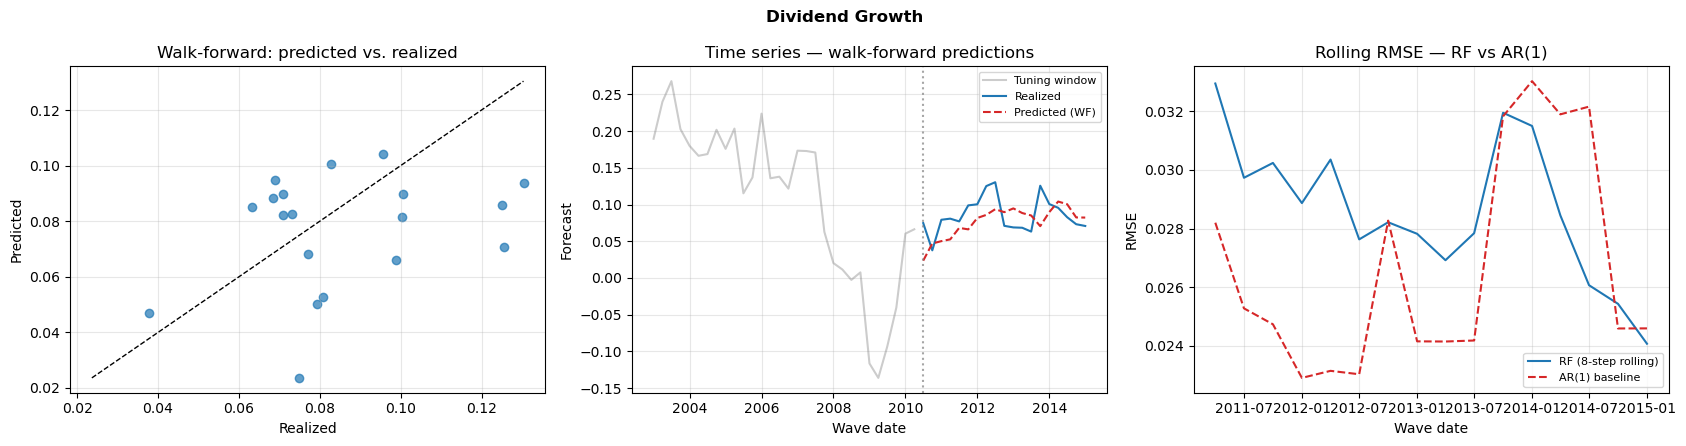

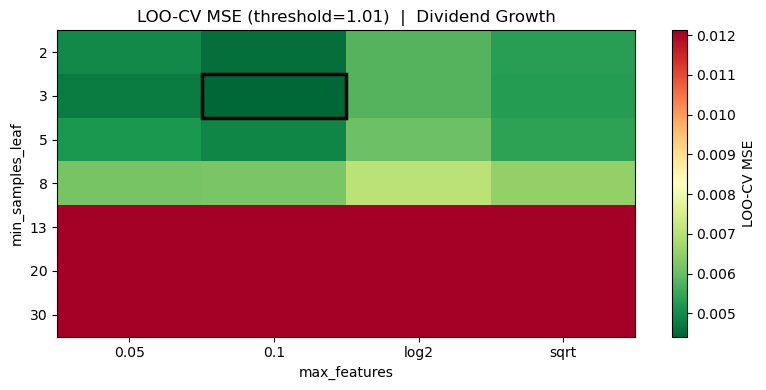

Saved to output/dividend_growth/

  earnings_growth
Settings: min_train_waves=40, use_variance=False, feature_dim=768


/tmp/ipykernel_2820410/3697327106.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(


Waves with coverage: 157  (1976-01-01 → 2015-01-01)
Articles/wave — median raw: 2311, kept (threshold=0.9): 1633 (70.9%)

Tuning on first 40 waves (LOO-CV, tune_n_estimators=100)...


Threshold:   0%|          | 0/5 [00:00<?, ?it/s]

Best params: {'neutral_threshold': 0.75, 'min_samples_leaf': 5, 'max_features': 0.1}
Best LOO-CV MSE: 0.00262
Re-aggregating at neutral_threshold=0.75...

Walk-forward evaluation (117 steps)...


Walk-forward:   0%|          | 0/117 [00:00<?, ?it/s]


Walk-forward RMSE — RF: 0.2517  |  AR(1): 0.1361
Walk-forward R²: 0.209
Directional accuracy: 55.2%

Refitting final model on all waves...
In-sample R² (full fit): 0.782  (use walk-forward R² for honest evaluation)


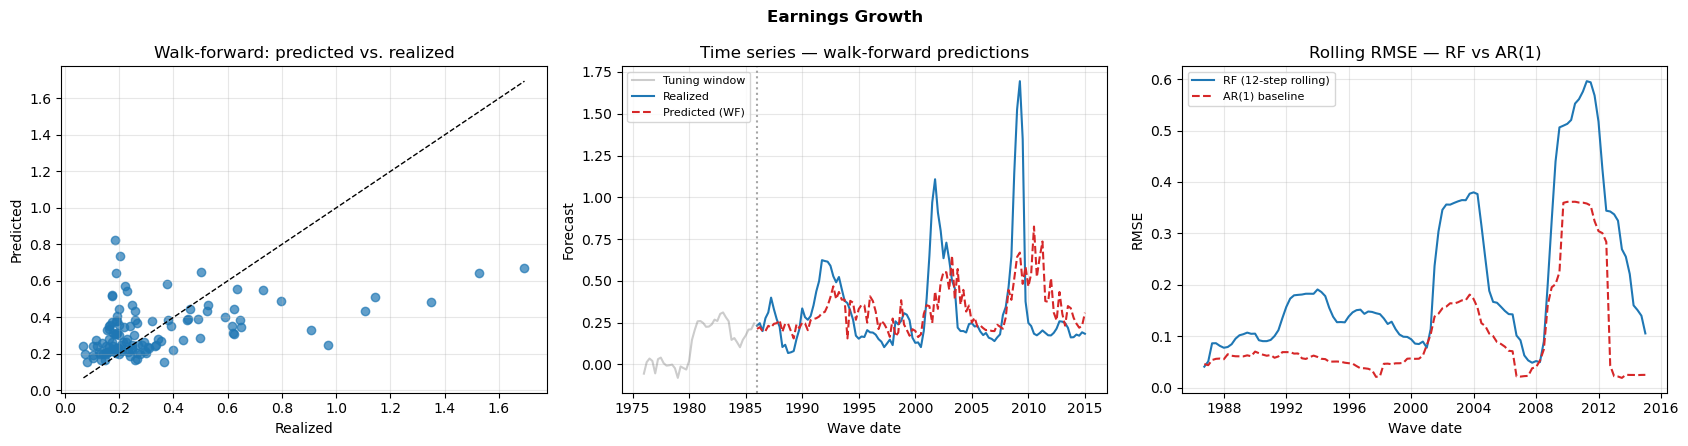

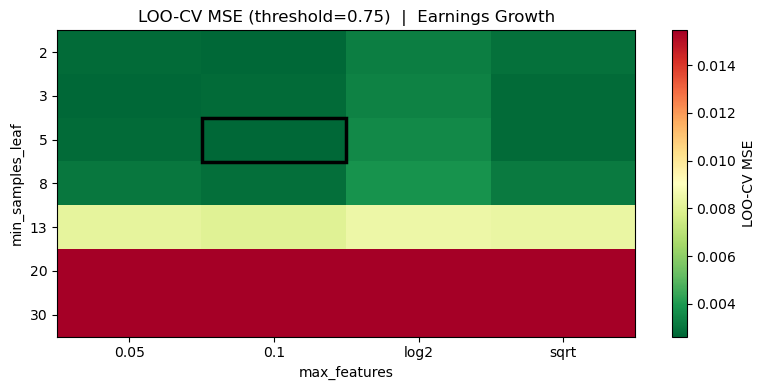

Saved to output/earnings_growth/


In [10]:
all_results = {}
for series_name, loader in SURVEY_SERIES.items():
    all_results[series_name] = run_pipeline(
        series_name, loader, news_df, article_embeddings,
        p_neutral_all=p_neutral_all,   # pre-cached — no forward passes at runtime
    )

In [11]:
print("\n── Walk-Forward Summary ──────────────────────────────────────────────────────────")
print(f"{'Series':<25} {'WF RMSE':>10} {'AR(1)':>8} {'WF R²':>7} "
      f"{'DirAcc':>8} {'thresh':>7} {'msl':>5} {'max_feat':>10} {'var':>5}")
print("-" * 95)
for name, res in all_results.items():
    bp = res["best_params"]
    print(f"{name:<25} {res['wf_rmse']:>10.4f} {res['ar1_rmse']:>8.4f} "
          f"{res['wf_r2']:>7.3f} {res['dir_acc']:>7.1%} "
          f"{bp['neutral_threshold']:>7.2f} {bp['min_samples_leaf']:>5} "
          f"{str(bp['max_features']):>10} {str(res['use_variance']):>5}")
print()
print("WF RMSE and R² are walk-forward (honest). thresh = tuned neutral filter cutoff.")
print("var = within-wave variance features appended (True for earnings_growth only).")


── Walk-Forward Summary ──────────────────────────────────────────────────────────
Series                       WF RMSE    AR(1)   WF R²   DirAcc  thresh   msl   max_feat   var
-----------------------------------------------------------------------------------------------
dividend_growth               0.0275   0.0258  -0.421   61.1%    1.01     3        0.1 False
earnings_growth               0.2517   0.1361   0.209   55.2%    0.75     5        0.1 False

WF RMSE and R² are walk-forward (honest). thresh = tuned neutral filter cutoff.
var = within-wave variance features appended (True for earnings_growth only).


## Explainability

Five lenses on what the Random Forest has learned.  All weight vectors are
derived from the **final model** (refit on all calibration waves) rather than
the walk-forward models, since the final model has seen the most data.

1. **Vocabulary saliency + word clouds** — project every FinBERT token through
   the RF's mean feature-importance-weighted embedding direction.
2. **Attention × gradient attribution** — per-headline token-level saliency via
   attention × gradient.
3. **Feature importance factor interpretation** — which embedding dimensions the
   RF uses most, and what tokens load onto those directions.
4. **Wave influence (Cook's D proxy)** — which calibration quarters most shift
   predictions when left out; surfaces top headlines from those quarters.
5. **Temporal saliency** — raw embedding signal vs. survey target over time,
   including the pre-calibration historical period.

### Explainability setup — shared helpers

In [12]:
# ── Explainability imports ────────────────────────────────────────────────────
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wordcloud", "-q"])
    from wordcloud import WordCloud

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

DIVMAP = LinearSegmentedColormap.from_list("rdbu_custom",
                                           ["#d62728", "#ffffff", "#1f77b4"])

def signed_wordcloud(word_scores, title, ax, max_words=80):
    abs_scores = {w: abs(s) for w, s in word_scores.items() if abs(s) > 1e-9}
    if not abs_scores:
        ax.text(0.5, 0.5, "No tokens", ha="center", va="center")
        ax.set_title(title); ax.axis("off"); return
    norm = Normalize(vmin=min(word_scores.values()), vmax=max(word_scores.values()))
    def colour_fn(word, font_size, position, orientation, random_state=None, **kw):
        rgba = DIVMAP(norm(word_scores.get(word, 0.0)))
        return tuple(int(255 * c) for c in rgba[:3])
    wc = WordCloud(width=800, height=400, background_color="white",
                   max_words=max_words, prefer_horizontal=0.9,
                   color_func=colour_fn).generate_from_frequencies(abs_scores)
    ax.imshow(wc, interpolation="bilinear"); ax.set_title(title, fontsize=11,
    fontweight="bold"); ax.axis("off")

def add_colorbar(fig, ax, label="← bearish     bullish →"):
    sm = ScalarMappable(cmap=DIVMAP, norm=Normalize(vmin=-1, vmax=1))
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.03, pad=0.02)
    cb.set_label(label, fontsize=9)
    cb.set_ticks([-1, 0, 1]); cb.set_ticklabels(["bearish", "neutral", "bullish"])


def get_rf_embedding_weights(rf_model, Z, y):
    """
    Reconstruct an approximate signed weight vector in the 768-dim embedding
    space from a RandomForestRegressor.

    Method: feature_importances_ gives the mean decrease in impurity per
    embedding dimension (unsigned).  We recover the sign by computing the
    Pearson correlation between each embedding dimension and the target across
    calibration waves — positive correlation → bullish dimension.

    Returns w_emb of shape (768,).
    """
    importances = rf_model.feature_importances_           # (768,) unsigned
    # Sign: correlation between each dim and target
    Z_centered = Z - Z.mean(axis=0)
    y_centered = y - y.mean()
    corr = (Z_centered * y_centered[:, None]).mean(axis=0)  # (768,)
    corr_sign  = np.sign(corr)
    w_emb      = importances * corr_sign                  # signed importance
    return w_emb


# Pre-compute RF embedding weights for all series
rf_weights_cache = {}
for series_name, res in all_results.items():
    w_emb = get_rf_embedding_weights(res["model"], res["Z"], res["y"])
    rf_weights_cache[series_name] = w_emb
    print(f"{series_name}: weight vector computed  "
          f"(max |w|={np.abs(w_emb).max():.5f}, "
          f"n_nonzero={np.sum(np.abs(w_emb) > 1e-8):,})")

print("\nExplainability helpers loaded.")

dividend_growth: weight vector computed  (max |w|=0.03796, n_nonzero=736)
earnings_growth: weight vector computed  (max |w|=0.03159, n_nonzero=766)

Explainability helpers loaded.


### 1 — Vocabulary saliency word cloud

**Method:** For every token in FinBERT's WordPiece vocabulary (~28k tokens after
filtering), we embed an isolated `"[CLS] <token> [SEP]"` sequence and project
the CLS vector onto the signed RF importance weight vector `w_emb` (feature
importances × correlation sign, mapped back to the full 768-dim space).

The scalar dot product is each token's marginal loading — how strongly that
word, if present in a headline, pushes the prediction up (bullish, blue) or
down (bearish, red).  Font size is proportional to |loading|.

In [13]:
VOCAB_WC_MAX_WORDS   = 100
VOCAB_WC_BATCH       = 256
VOCAB_WC_MIN_LEN     = 3
VOCAB_WC_SKIP_HASHES = True

vocab_saliency_cache = {}

# Build corpus vocabulary once — tokens that never appear in any headline
# have meaningless isolated embeddings and are excluded from saliency scoring.
print("Building corpus vocabulary...")
corpus_token_set = set()
for i in tqdm(range(0, len(news_df), 1000), desc="Tokenising corpus"):
    batch = news_df["text"].iloc[i:i+1000].dropna().tolist()
    for text in batch:
        corpus_token_set.update(tokenizer.tokenize(text))
print(f"Corpus vocabulary: {len(corpus_token_set):,} unique tokens")


def compute_vocab_saliency(w_emb, batch_size=VOCAB_WC_BATCH):
    """
    Score every token in the FinBERT vocabulary that actually appears
    in the news corpus.  Tokens absent from the corpus are excluded —
    their isolated CLS embeddings have no influence on any prediction
    and produce spurious saliency scores.
    """
    vocab   = tokenizer.get_vocab()
    special = set(tokenizer.all_special_tokens)
    w       = w_emb.astype(np.float32)

    candidates = [
        (tok, tid) for tok, tid in vocab.items()
        if tok not in special
        and not (VOCAB_WC_SKIP_HASHES and tok.startswith("##"))
        and len(tok) >= VOCAB_WC_MIN_LEN
        and any(c.isalpha() for c in tok)
        and tok in corpus_token_set          # only tokens present in corpus
    ]
    print(f"Scoring {len(candidates):,} corpus tokens "
          f"(of {len(vocab):,} total vocabulary)...")

    model.eval()
    saliency = {}
    for i in tqdm(range(0, len(candidates), batch_size), desc="Vocab embed"):
        batch  = candidates[i:i+batch_size]
        texts  = [t for t, _ in batch]
        inputs = tokenizer(texts, return_tensors="pt", padding=True,
                           truncation=True, max_length=16)
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        with torch.no_grad():
            out = model(**inputs)
        cls = out.last_hidden_state[:, 0, :].cpu().numpy().astype(np.float32)
        for (tok, _), s in zip(batch, cls @ w):
            saliency[tok] = float(s)
    return saliency


for series_name, w_emb in rf_weights_cache.items():
    sal = compute_vocab_saliency(w_emb)
    vocab_saliency_cache[series_name] = sal
    sorted_sal = sorted(sal.items(), key=lambda x: x[1])
    print(f"\n{series_name} — top 10 bearish:")
    for tok, s in sorted_sal[:10]:
        print(f"  {tok:<20s}  {s:+.5f}")
    print(f"{series_name} — top 10 bullish:")
    for tok, s in sorted_sal[-10:][::-1]:
        print(f"  {tok:<20s}  {s:+.5f}")

Building corpus vocabulary...


Tokenising corpus:   0%|          | 0/1450 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (596 > 512). Running this sequence through the model will result in indexing errors


Corpus vocabulary: 25,796 unique tokens
Scoring 20,029 corpus tokens (of 30,522 total vocabulary)...


Vocab embed:   0%|          | 0/79 [00:00<?, ?it/s]


dividend_growth — top 10 bearish:
  but                   -0.30669
  yet                   -0.29606
  there                 -0.28147
  that                  -0.27843
  already               -0.27580
  verses                -0.26766
  especially            -0.26335
  asked                 -0.26061
  still                 -0.26040
  tho                   -0.25941
dividend_growth — top 10 bullish:
  media                 +0.13632
  inc                   +0.13000
  bonds                 +0.12284
  remixes               +0.10361
  iii                   +0.10172
  key                   +0.10040
  cbs                   +0.09844
  records               +0.09817
  llc                   +0.09731
  assists               +0.09667
Scoring 20,029 corpus tokens (of 30,522 total vocabulary)...


Vocab embed:   0%|          | 0/79 [00:00<?, ?it/s]


earnings_growth — top 10 bearish:
  counsel               -0.32242
  effective             -0.31554
  voted                 -0.29875
  organise              -0.29800
  autonomy              -0.29647
  conductor             -0.29416
  funds                 -0.29409
  interview             -0.29278
  llc                   -0.29208
  associates            -0.28966
earnings_growth — top 10 bullish:
  but                   -0.02184
  results               -0.05069
  mark                  -0.07584
  however               -0.07597
  bottom                -0.08379
  bard                  -0.08517
  result                -0.09176
  bad                   -0.09448
  playoffs              -0.09531
  counterparts          -0.09697


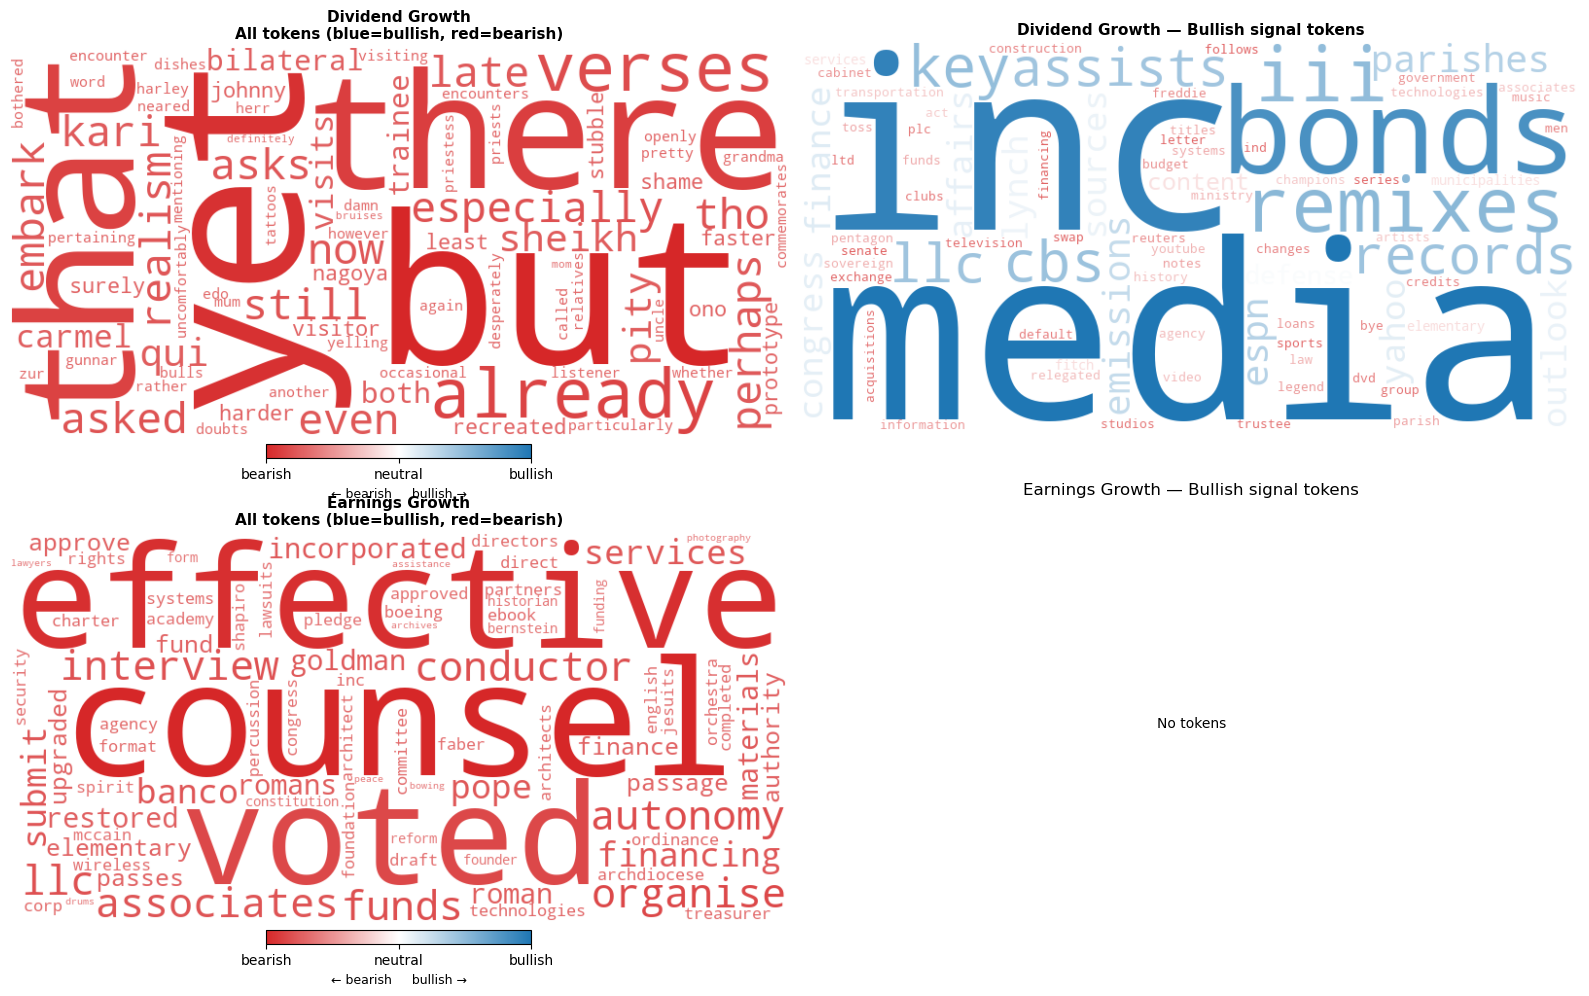

Saved wordcloud_vocab_saliency.png


In [14]:
# ── Plot word clouds (one row per series) ─────────────────────────────────────
n_series = len(vocab_saliency_cache)
fig, axes = plt.subplots(n_series, 2, figsize=(16, 5 * n_series))
if n_series == 1:
    axes = axes[None, :]   # ensure 2D indexing

for row, (series_name, sal) in enumerate(vocab_saliency_cache.items()):
    pos_sal = {w: s for w, s in sal.items() if s > 0}
    neg_sal = {w: abs(s) for w, s in sal.items() if s < 0}

    signed_wordcloud(
        {w: s for w, s in sal.items()},
        f"{series_name.replace('_',' ').title()}\nAll tokens (blue=bullish, red=bearish)",
        axes[row, 0],
    )
    # Separate positive cloud
    signed_wordcloud(
        pos_sal,
        f"{series_name.replace('_',' ').title()} — Bullish signal tokens",
        axes[row, 1],
    )
    add_colorbar(fig, axes[row, 0])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "wordcloud_vocab_saliency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved wordcloud_vocab_saliency.png")

### 2 — Attention × gradient attribution (per-headline)

For a specific headline we compute *attention flow* saliency:

```
saliency(token_i) = Σ_heads  attention_weight(CLS → token_i)  ×  |∂ŷ/∂attention_weight|
```

This tells us which tokens the model's attention mechanism was *both* attending to
*and* sensitive to (gradient-wise) when forming the CLS representation used for
prediction.  It is computed per-headline, so you can inspect any article in the corpus.

Two views are produced:
- **Bar chart** of per-token saliency scores for the selected headline.
- **Heatmap** of raw attention weights across all heads in the last layer.

In [15]:
def attention_gradient_saliency(text, reg_weights_emb, layer_idx=-1):
    """Attention × gradient saliency for one headline."""
    inputs    = tokenizer(text, return_tensors="pt", truncation=True,
                          max_length=MAX_TOKEN_LEN, padding=False)
    tokens    = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    inputs    = {k: v.to(DEVICE) for k, v in inputs.items()}
    model.eval()
    for p in model.parameters(): p.requires_grad_(False)
    outputs   = model(**inputs, output_attentions=True)
    cls_emb   = outputs.last_hidden_state[:, 0, :]
    w_t       = torch.tensor(reg_weights_emb, dtype=torch.float32, device=DEVICE)
    pred      = (cls_emb * w_t).sum()
    attn      = outputs.attentions[layer_idx]
    attn.retain_grad()
    pred.backward()
    attn_np   = attn.detach().cpu().numpy()[0]
    grad_np   = attn.grad.cpu().numpy()[0]
    token_sal = (attn_np[:, 0, :] * np.abs(grad_np[:, 0, :])).sum(axis=0)
    token_sal = token_sal / (token_sal.sum() + 1e-9)
    for p in model.parameters(): p.requires_grad_(False)
    return tokens, token_sal, attn_np.mean(axis=0)


def plot_attribution(text, reg_weights_emb, series_name):
    tokens, token_sal, mean_attn = attention_gradient_saliency(text, reg_weights_emb)
    disp_tok, disp_sal = [], []
    for tok, sv in zip(tokens, token_sal):
        if tok.startswith("##") and disp_tok:
            disp_tok[-1] += tok[2:]; disp_sal[-1] += sv
        else:
            disp_tok.append(tok); disp_sal.append(sv)

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(disp_tok)*0.28+1)))
    short = (text[:70]+"…") if len(text) > 70 else text
    fig.suptitle(f"Attribution  |  {series_name}\n\"{short}\"",
                 fontsize=10, fontweight="bold")

    ax = axes[0]
    ax.barh(range(len(disp_tok)), disp_sal,
            color=["#1f77b4" if s >= 0 else "#d62728" for s in disp_sal], alpha=0.85)
    ax.set_yticks(range(len(disp_tok))); ax.set_yticklabels(disp_tok, fontsize=9)
    ax.invert_yaxis(); ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Attention × gradient saliency")
    ax.set_title("Per-token attribution"); ax.grid(alpha=0.3, axis="x")

    ax = axes[1]
    n_show = min(len(tokens), 30)
    ax.bar(range(n_show), mean_attn[0, :n_show], color="#2ca02c", alpha=0.8)
    ax.set_xticks(range(n_show))
    ax.set_xticklabels(tokens[:n_show], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Mean attention (CLS → token)")
    ax.set_title("Raw attention (mean heads)"); ax.grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"attribution_{series_name}.png", dpi=150, bbox_inches="tight")
    plt.show()


# Demo: attribute most extreme walk-forward step per series
for series_name, res in all_results.items():
    w_emb   = rf_weights_cache[series_name]
    wf_df   = res["wf_df"]
    extreme = wf_df.loc[wf_df["error"].abs().idxmax()]
    wd      = pd.Timestamp(extreme["wave_date"])
    mask    = (
        (news_df["date"] >= wd - pd.Timedelta(days=AGG_WINDOW_DAYS)) &
        (news_df["date"] <  wd)
    )
    headlines = news_df.loc[mask, "text"].tolist()
    if not headlines:
        print(f"No headlines for {series_name} near {wd.date()}, skipping.")
        continue
    print(f"\n{series_name} — largest WF error: {extreme['error']:+.4f} ({wd.date()})")
    print(f"Attributing: \"{headlines[0][:80]}\"")
    plot_attribution(headlines[0], w_emb, series_name)

[transformers] `sdpa` attention does not support `output_attentions=True`. Please set your attention to `eager` if you want any of these features.



dividend_growth — largest WF error: +0.0551 (2013-10-01)
Attributing: "Americans Show Sharp Divide on Intervention"


IndexError: tuple index out of range

### 3 — Feature importance factor interpretation

The RF assigns a mean-decrease-in-impurity importance to each of the 768 embedding
dimensions.  We identify the top-K most important dimensions, then find the
vocabulary tokens whose FinBERT embeddings are most aligned with each of those
directions — revealing what semantic content the forest is keying on.

In [ ]:
RF_INTERP_TOP_K_DIMS = 5
RF_INTERP_TOP_N_WORDS = 10


def interpret_rf_factors(rf_model, vocab_saliency_dict,
                          n_dims=RF_INTERP_TOP_K_DIMS,
                          n_words=RF_INTERP_TOP_N_WORDS):
    """
    Find the top-K embedding dimensions by RF feature importance, then identify
    the vocabulary tokens most and least aligned with each dimension direction.
    """
    importances  = rf_model.feature_importances_
    top_dim_idx  = np.argsort(importances)[::-1][:n_dims]
    results      = []

    # We need per-token embeddings — reuse the top-2000 most salient tokens
    top_tokens = sorted(vocab_saliency_dict.items(),
                        key=lambda x: abs(x[1]), reverse=True)[:2000]
    toks_list  = [t for t, _ in top_tokens]

    # Embed in batches, store full 768-dim CLS vectors
    all_cls = []
    model.eval()
    for i in range(0, len(toks_list), 256):
        batch  = toks_list[i:i+256]
        inp    = tokenizer(batch, return_tensors="pt", padding=True,
                           truncation=True, max_length=16)
        inp    = {k: v.to(DEVICE) for k, v in inp.items()}
        with torch.no_grad():
            out = model(**inp)
        all_cls.append(out.last_hidden_state[:, 0, :].cpu().numpy())
    all_cls = np.vstack(all_cls).astype(np.float32)   # (2000, 768)

    for dim_idx in top_dim_idx:
        proj       = all_cls[:, dim_idx]               # projection onto this dim
        sorted_idx = np.argsort(proj)
        top_neg    = [(toks_list[j], float(proj[j])) for j in sorted_idx[:n_words]]
        top_pos    = [(toks_list[j], float(proj[j])) for j in sorted_idx[-n_words:][::-1]]
        results.append({
            "dim_idx":    dim_idx,
            "importance": float(importances[dim_idx]),
            "top_pos":    top_pos,
            "top_neg":    top_neg,
        })
    return results


for series_name, res in all_results.items():
    print(f"\n{'='*60}")
    print(f"  Feature importance interpretation: {series_name}")
    print(f"{'='*60}")
    interp = interpret_rf_factors(res["model"], vocab_saliency_cache[series_name])

    fig, axes = plt.subplots(RF_INTERP_TOP_K_DIMS, 2,
                             figsize=(14, 3.5 * RF_INTERP_TOP_K_DIMS))
    fig.suptitle(
        f"Top-{RF_INTERP_TOP_K_DIMS} embedding dims by RF importance\n"
        f"{series_name.replace('_',' ').title()}",
        fontweight="bold", fontsize=12
    )
    for row, info in enumerate(interp):
        pos_words, pos_vals = zip(*info["top_pos"]) if info["top_pos"] else ([], [])
        neg_words, neg_vals = zip(*info["top_neg"]) if info["top_neg"] else ([], [])

        ax = axes[row, 0]
        ax.barh(range(len(pos_words)), pos_vals, color="#1f77b4", alpha=0.85)
        ax.set_yticks(range(len(pos_words))); ax.set_yticklabels(pos_words, fontsize=9)
        ax.invert_yaxis()
        ax.set_title(f"Dim {info['dim_idx']}  |  importance={info['importance']:.5f}\n"
                     f"Top aligned tokens", fontsize=9)
        ax.set_xlabel("Raw CLS value on this dim"); ax.grid(alpha=0.3, axis="x")

        ax = axes[row, 1]
        ax.barh(range(len(neg_words)), [abs(v) for v in neg_vals],
                color="#d62728", alpha=0.85)
        ax.set_yticks(range(len(neg_words))); ax.set_yticklabels(neg_words, fontsize=9)
        ax.invert_yaxis()
        ax.set_title("Anti-aligned tokens", fontsize=9)
        ax.set_xlabel("|Raw CLS value|"); ax.grid(alpha=0.3, axis="x")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"rf_factors_{series_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

### 4 — Wave influence analysis (Cook's D proxy)

For each calibration wave we refit the Random Forest at the tuned hyperparameters
with that wave left out, measure how much the full-sample prediction vector
shifts, and compute an approximate Cook's D influence score.

High-influence quarters are flagged in red and their top headlines are printed
for qualitative inspection — useful for identifying whether the model is keying
on real macro events or data artefacts.

In [ ]:
INFLUENCE_TOP_K        = 10
INFLUENCE_TOP_HEADLINES = 3


def cook_d_influence_rf(Z, y, best_params, n_estimators=RF_N_ESTIMATORS):
    """Cook's D proxy for RandomForestRegressor via LOO re-fits."""
    n, p  = Z.shape
    m_full = RandomForestRegressor(
        n_estimators=n_estimators, random_state=SEED, n_jobs=-1,
        **best_params
    )
    m_full.fit(Z, y)
    y_hat = m_full.predict(Z)
    mse   = np.mean((y - y_hat) ** 2)

    influence = np.zeros(n)
    for i in tqdm(range(n), desc="Cook's D LOO"):
        idx   = np.concatenate([np.arange(i), np.arange(i+1, n)])
        m_loo = RandomForestRegressor(
            n_estimators=n_estimators, random_state=SEED, n_jobs=-1,
            **best_params
        )
        m_loo.fit(Z[idx], y[idx])
        delta         = m_loo.predict(Z) - y_hat
        influence[i]  = (delta @ delta) / (p * mse + 1e-12)
    return influence


for series_name, res in all_results.items():
    print(f"\n{'='*60}")
    print(f"  Influence analysis: {series_name}")
    print(f"{'='*60}")
    Z, y    = res["Z"], res["y"]
    waves   = res["waves_df"]
    n       = len(Z)

    influence = cook_d_influence_rf(Z, y, res["best_params"])
    top_idx   = np.argsort(influence)[::-1][:INFLUENCE_TOP_K]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    fig.suptitle(f"Wave influence  |  {series_name.replace('_',' ').title()}",
                 fontweight="bold")

    colors = ["#d62728" if i in top_idx else "#aec7e8" for i in range(n)]
    ax = axes[0]
    ax.bar(range(n), influence, color=colors, alpha=0.85)
    step = max(1, n // 8)
    ax.set_xticks(range(0, n, step))
    ax.set_xticklabels(
        [waves["wave_date"].iloc[i].strftime("%Y-%m") for i in range(0, n, step)],
        rotation=45, ha="right", fontsize=8
    )
    ax.set_ylabel("Cook's D"); ax.set_title("Influence by wave (red = top 10)")
    ax.grid(alpha=0.3, axis="y")

    ax = axes[1]
    ax.barh(range(INFLUENCE_TOP_K),
            [influence[i] for i in top_idx], color="#d62728", alpha=0.85)
    ax.set_yticks(range(INFLUENCE_TOP_K))
    ax.set_yticklabels(
        [waves["wave_date"].iloc[i].strftime("%Y-%m") for i in top_idx], fontsize=9
    )
    ax.invert_yaxis()
    ax.set_xlabel("Cook's D"); ax.set_title("Top influential waves")
    ax.grid(alpha=0.3, axis="x")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"wave_influence_{series_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nTop {INFLUENCE_TOP_K} influential waves + sample headlines:")
    for rank, wi in enumerate(top_idx):
        wd   = waves["wave_date"].iloc[wi]
        mask = (
            (news_df["date"] >= wd - pd.Timedelta(days=AGG_WINDOW_DAYS)) &
            (news_df["date"] <  wd)
        )
        hlines = news_df.loc[mask, ["date","text"]].head(INFLUENCE_TOP_HEADLINES)
        print(f"\n  [{rank+1}] {wd.strftime('%Y-%m')}  influence={influence[wi]:.4f}")
        for _, row in hlines.iterrows():
            print(f"       {row['date'].strftime('%Y-%m-%d')}  {row['text'][:90]}")

### 5 — Temporal saliency: bullish/bearish signal over time

Aggregate each article's scalar saliency score (embedding dot regression weight)
across all articles in each quarter, then plot alongside the actual survey forecast.
This shows whether the model's *raw signal* tracks the target before any regression
fitting — a sanity check on whether FinBERT is picking up economically meaningful
variation, and a useful diagnostic for the historical extrapolation period.

In [ ]:
def compute_wave_signal(news_df, article_embeddings, reg_weights_emb,
                         survey_df, p_neutral_all=None,
                         neutral_threshold=NEUTRAL_THRESHOLD,
                         window_days=AGG_WINDOW_DAYS,
                         scheme=RECENCY_WEIGHTING,
                         halflife=RECENCY_HALFLIFE_DAYS):
    """Recency-weighted mean embedding signal per wave.
    Uses pre-cached p_neutral_all for filtering — no forward passes."""
    w, sig = reg_weights_emb.astype(np.float32), {}
    for _, row in survey_df.iterrows():
        wd   = row["wave_date"]
        mask = (
            (news_df["date"] >= wd - pd.Timedelta(days=window_days)) &
            (news_df["date"] <  wd)
        )
        idx = np.where(mask)[0]
        if len(idx) == 0: continue
        emb = article_embeddings[idx].astype(np.float32)

        # Sentiment filter using pre-cached scores
        if p_neutral_all is not None and neutral_threshold < 1.0:
            p_neut = p_neutral_all[idx]
            keep   = p_neut <= neutral_threshold
            if keep.sum() == 0:
                keep[np.argmin(p_neut)] = True
            emb = emb[keep]
            idx = idx[keep]

        rw  = recency_weights(news_df.iloc[idx]["date"], wd, scheme, halflife)
        sig[wd] = float((emb @ w * rw).sum() / rw.sum())
    return pd.Series(sig).sort_index()


for series_name, res in all_results.items():
    from sklearn.preprocessing import minmax_scale
    w_emb      = rf_weights_cache[series_name]
    waves      = res["waves_df"]
    best_thresh = res["best_params"]["neutral_threshold"]
    survey     = waves[["wave_date", "median_forecast"]].copy()

    raw_signal   = compute_wave_signal(
        news_df, article_embeddings, w_emb, survey,
        p_neutral_all=p_neutral_all,
        neutral_threshold=best_thresh,
    )
    common_dates = raw_signal.index.intersection(survey.set_index("wave_date").index)
    sig_aligned  = raw_signal.loc[common_dates]
    tgt_aligned  = survey.set_index("wave_date").loc[common_dates, "median_forecast"]

    sig_norm = minmax_scale(sig_aligned.values)
    tgt_norm = minmax_scale(tgt_aligned.values)
    corr     = np.corrcoef(sig_aligned.values, tgt_aligned.values)[0, 1]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.suptitle(f"Temporal saliency  |  {series_name.replace('_',' ').title()}",
                 fontweight="bold")

    ax = axes[0]
    ax.plot(common_dates, tgt_aligned.values, color="C0", label="Survey forecast")
    ax.set_ylabel("Forecast value"); ax.legend(); ax.grid(alpha=0.3)
    ax.set_title("Raw survey target")

    ax = axes[1]
    ax.fill_between(common_dates, 0, sig_norm, alpha=0.35, color="C2",
                    label="RF embedding signal (normalised)")
    ax.plot(common_dates, tgt_norm, color="C0", ls="--", lw=1.5,
            label="Survey forecast (normalised)")
    ax.text(0.02, 0.92, f"Pearson r = {corr:.3f}", transform=ax.transAxes,
            fontsize=10, color="C2",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    ax.set_ylabel("Normalised [0,1]"); ax.set_xlabel("Wave date")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_title("Embedding signal vs. target (both normalised)")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"temporal_saliency_{series_name}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Raw signal–target correlation ({series_name}): {corr:.3f}")

## Optional: Fine-tuning FinBERT

The pipeline above keeps FinBERT entirely frozen. If hold-out performance
is unsatisfactory, the natural next step is to **unfreeze the final 1–2
transformer layers** and fine-tune them jointly with a thin regression head,
using your survey labels as the supervision signal.

### Why only the last 1–2 layers?

FinBERT's early layers encode low-level syntax and subword patterns that
transfer cleanly across tasks. The final layers encode task-specific
representations that were optimised for masked language modelling on financial
text — *not* for predicting survey expectations. Unfreezing only these layers
lets the model adapt its representations toward your target without
catastrophically forgetting the pre-trained linguistic structure.

### Implementation sketch

```python
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup

# 1. Load FinBERT with a regression head (num_labels=1)
ft_model = AutoModelForSequenceClassification.from_pretrained(
    ENCODER_NAME, num_labels=1
).to(DEVICE)

# 2. Freeze all layers except the last encoder block and the pooler
for name, param in ft_model.named_parameters():
    if not any(layer in name for layer in ["encoder.layer.11", "encoder.layer.10", "pooler"]):
        param.requires_grad = False

# 3. Confirm trainable parameter count
n_trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_trainable:,}")  # expect ~7-14M, not 110M

# 4. Construct wave-level dataset: one forward pass per article in the window,
#    aggregate CLS embeddings with recency weights, then regress on survey target.
#    OR: treat the mean-pooled headline set as a "document" and fine-tune directly.

# 5. Training setup — very conservative to avoid overfitting at small N
optimizer = torch.optim.AdamW(
    [p for p in ft_model.parameters() if p.requires_grad],
    lr=1e-5,           # 10x smaller than typical fine-tuning; critical at N<150
    weight_decay=0.01,
)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=5,
    num_training_steps=50,  # total gradient steps; with LOO this is n_calib * n_epochs
)

# 6. LOO-CV loop (same structure as the frozen pipeline) to select n_epochs.
#    Typical grid: [5, 10, 20] epochs.  Early stopping on val loss recommended.

# 7. After fine-tuning, re-encode all articles with the updated model,
#    cache new embeddings, and re-run the XGBoost pipeline as normal.
```

### Practical cautions

- With N ≈ 40–120 quarterly waves, even 2 unfrozen layers is high risk.
  Monitor LOO-CV MSE carefully — it should improve over the frozen baseline
  or the fine-tuning is overfitting.
- Use a **much lower learning rate** than standard BERT fine-tuning
  (1e-5 vs. the typical 2e-5 to 5e-5).  The small dataset cannot absorb
  large weight updates.
- **Do not** fine-tune on the full article corpus — only the wave-aggregated
  signal is supervised.  The encoder update comes from the survey loss, not
  from re-running the LM objective.
- Re-generate and re-cache article embeddings after fine-tuning; the frozen
  cache is no longer valid once any weights change.

## Historical Extrapolation

**TODO:** Once you have the full news corpus, load it here and call
`run_pipeline` again or extend `run_pipeline` to accept a historical
news DataFrame. The `model.pkl` saved above contains everything needed
(`ridge`, `pca`, fitted means) to call `ridge.predict()` on any new
aggregated embedding matrix.

For now with the PoC sample (1965–2014), the news corpus already covers
the full period so the calibration results above are your extrapolation.